# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

# **LOAD DATASET**

In [3]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [4]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.columns)

(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


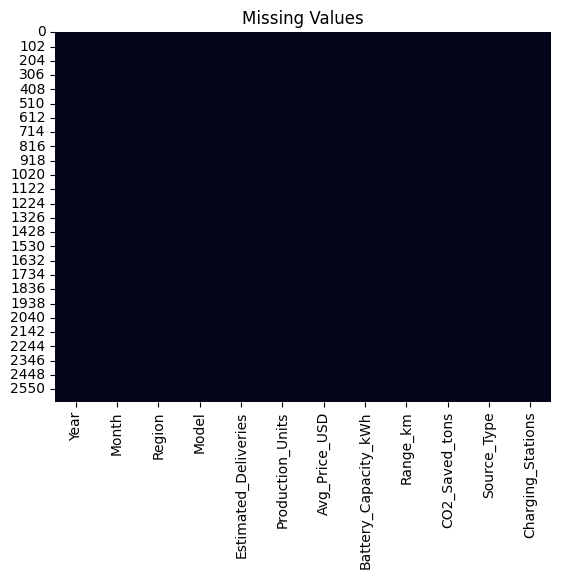

In [6]:
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [7]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [8]:
print(df.describe().T)

                       count          mean           std       min        25%  \
Year                  2640.0   2020.000000      3.162877   2015.00   2017.000   
Month                 2640.0      6.500000      3.452707      1.00      3.750   
Estimated_Deliveries  2640.0   9922.199621   3935.950093     48.00   7292.000   
Production_Units      2640.0  10655.847348   4260.600858     50.00   7828.250   
Avg_Price_USD         2640.0  84907.340330  20123.258036  50003.70  67726.365   
Battery_Capacity_kWh  2640.0     87.059470     20.836265     60.00     75.000   
Range_km              2640.0    500.257576    120.868549    330.00    418.000   
CO2_Saved_tons        2640.0    744.076989    353.221224      3.07    499.620   
Charging_Stations     2640.0   8932.133712   3469.565883   3002.00   5897.750   

                            50%          75%        max  
Year                   2020.000    2023.0000    2025.00  
Month                     6.500       9.2500      12.00  
Estimated_Deliv

# **DISTIBUTION PLOT**

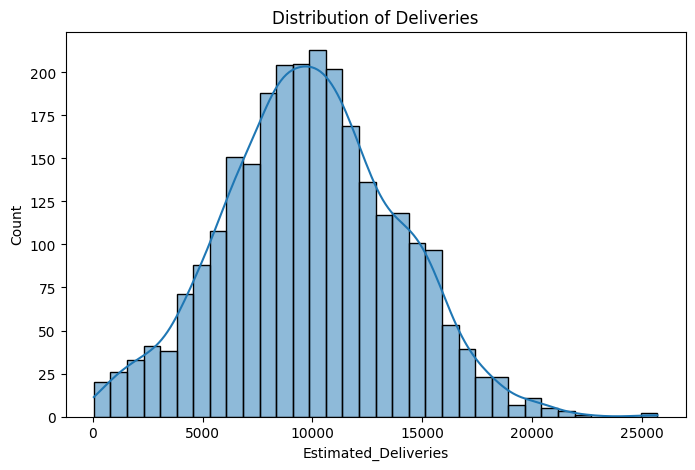

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title("Distribution of Deliveries")
plt.show()

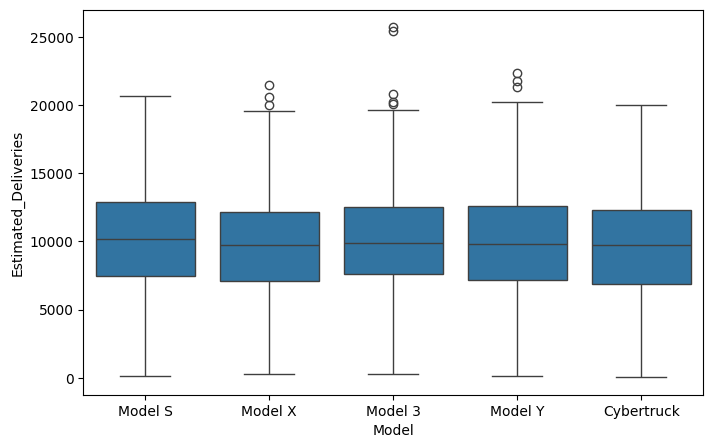

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Model', y='Estimated_Deliveries', data=df)
plt.show()

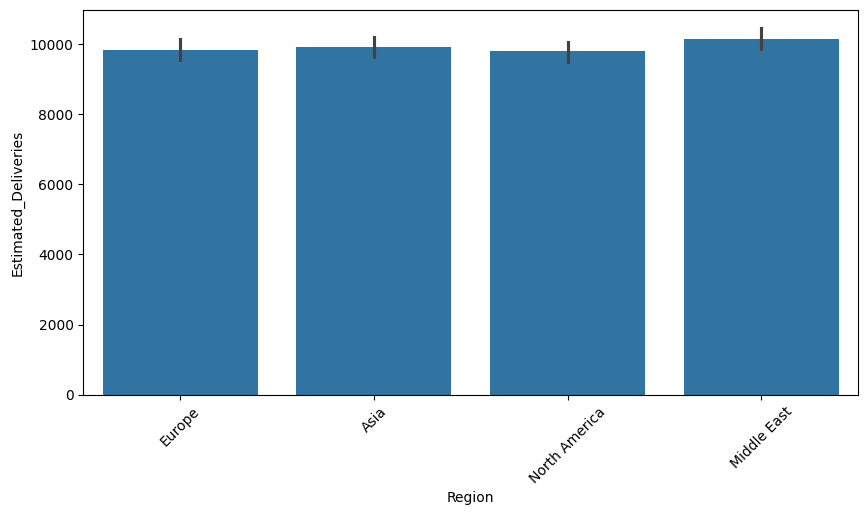

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x='Region', y='Estimated_Deliveries', data=df)
plt.xticks(rotation=45)
plt.show()

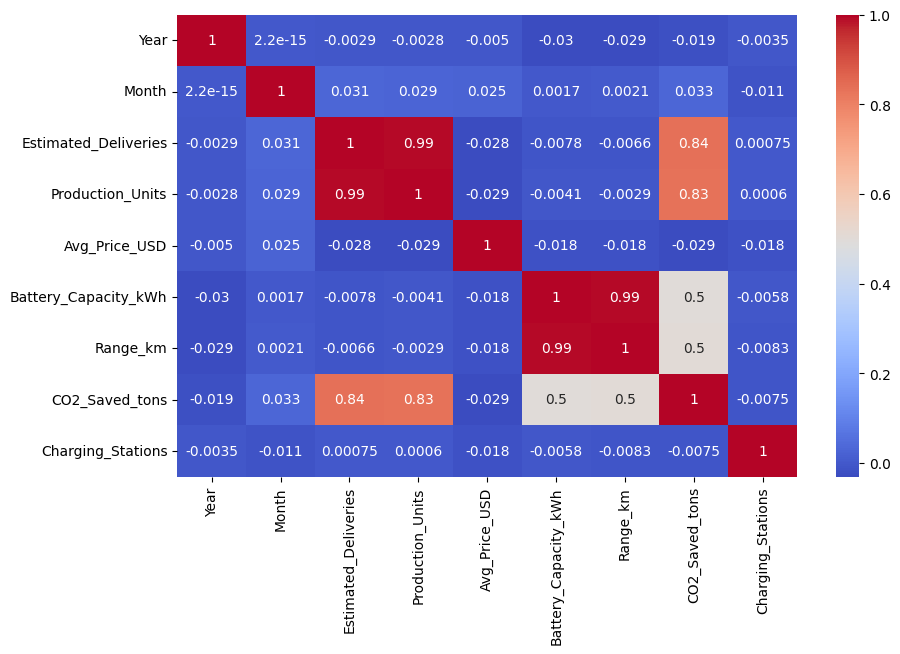

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

# **FEATURE ENGINEERING**

In [13]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

df['Quarter'] = df['Date'].dt.quarter

# **LABEL ENCODING**

In [14]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

# **FEATURE SELECTION**

In [15]:
target = 'Estimated_Deliveries'

In [16]:
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df[target]

# **TRAIN TEST SPLIT**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 12)
(528, 12)


# **LINEAR REGRESSION**

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2:",
      r2_score(y_test, lr_pred))

Linear Regression
MAE: 309.9983092854833
RMSE: 383.4678708971193
R2: 0.9901351961876611


# **DECISION TREE**

In [19]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")

print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2:",
      r2_score(y_test, dt_pred))

Decision Tree
MAE: 402.67424242424244
RMSE: 549.7480828028912
R2: 0.9797251366784144


# **RANDOM FOREST**

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2:",
      r2_score(y_test, rf_pred))

Random Forest
MAE: 323.2826136363636
RMSE: 408.23470255442146
R2: 0.9888197805601558


# **Hyperparameter Tuning**

In [21]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [22]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

**Feature Importance Analysis**

In [23]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
4       Production_Units    0.990722
8         CO2_Saved_tons    0.002411
7               Range_km    0.001422
5          Avg_Price_USD    0.001286
10     Charging_Stations    0.001124
0                   Year    0.000844
1                  Month    0.000633
3                  Model    0.000488
2                 Region    0.000414
9            Source_Type    0.000309
11               Quarter    0.000184
6   Battery_Capacity_kWh    0.000164


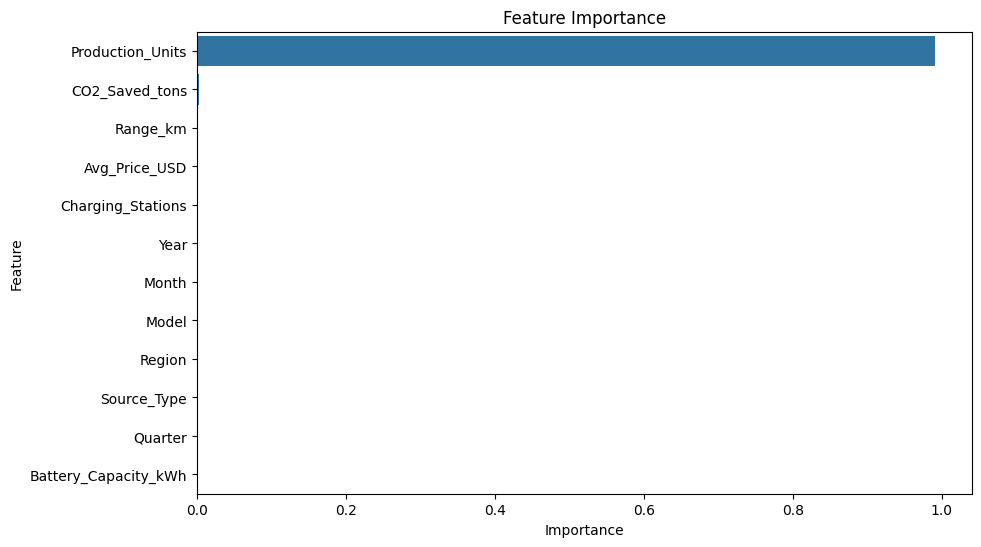

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# **Time Series Forecasting (ARIMA)**

In [25]:
ts = df.groupby('Date')[
    'Estimated_Deliveries'
].sum()

In [26]:
model = ARIMA(
    ts,
    order=(5,1,0)
)

arima_model = model.fit()

print(arima_model.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(5, 1, 0)   Log Likelihood               -1489.328
Date:                  Sat, 30 May 2026   AIC                           2990.656
Time:                          18:03:31   BIC                           3007.907
Sample:                      01-01-2015   HQIC                          2997.666
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5502      0.047    -11.712      0.000      -0.642      -0.458
ar.L2         -0.3591      0.050     -7.137      0.000      -0.458      -0.260
ar.L3         -0.2469      0.051    

In [27]:
forecast = arima_model.forecast(
    steps=12
)

print(forecast)

2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


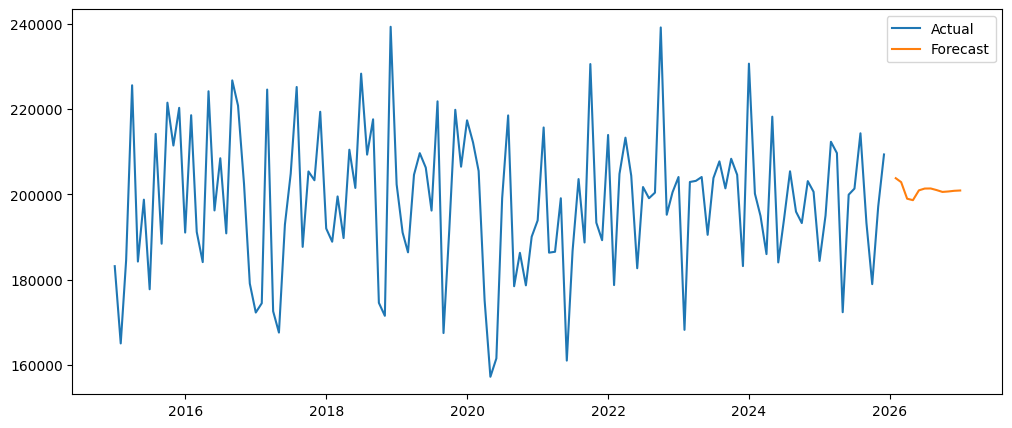

In [28]:
plt.figure(figsize=(12,5))

plt.plot(ts, label='Actual')

future_dates = pd.date_range(
    start=ts.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.legend()
plt.show()

# **Model Comparison**

In [29]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R2 Score':[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    'RMSE':[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

print(results)

               Model  R2 Score        RMSE
0  Linear Regression  0.990135  383.467871
1      Decision Tree  0.979725  549.748083
2      Random Forest  0.988820  408.234703


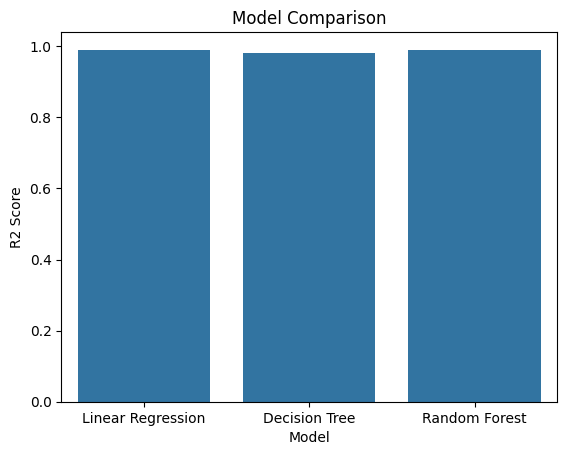

In [30]:
sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")
plt.show()

# **Actual vs Predicted Analysis**

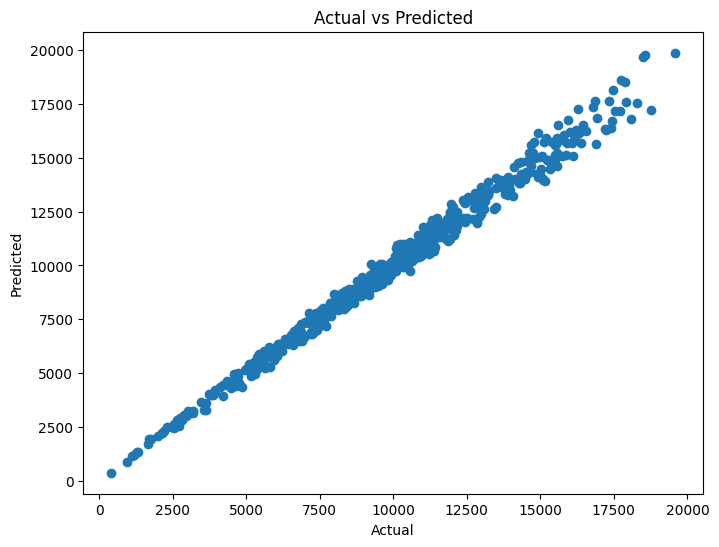

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

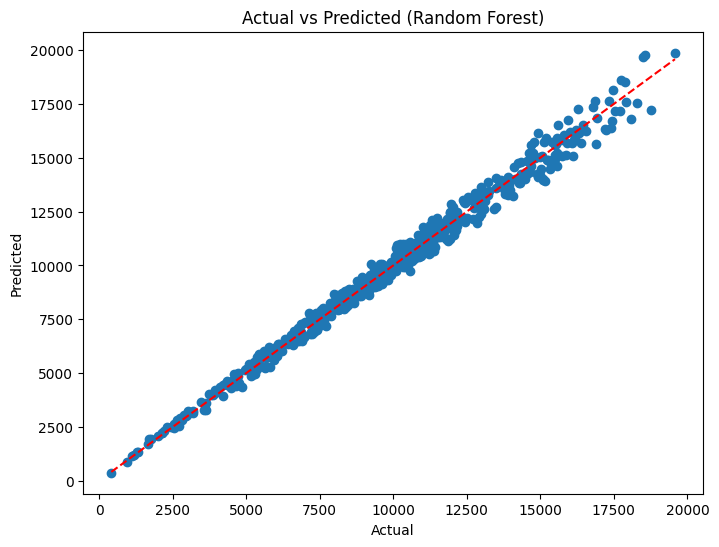

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted (Random Forest)")
plt.show()